# Prueba de conexion con el AFE5808A

En este documento se realizará una prueba de conexion con el AFE5808A a traves de petalinux usando la Kria Robotics KR260

### Importacion de la libreria del AFE SPI

En esta primera parte se evaluara la escritura de registros y lectura de datos en el register map a traves del slow control

In [1]:
import ctypes
import time

import matplotlib.pyplot as plt
import os
import mmap
import struct
import numpy as np
import subprocess

from dma_driver import *
from afe5808a import *

In [2]:
def run_command(command):
    """Ejecuta un comando en la terminal y muestra la salida en tiempo real."""
    process = subprocess.Popen(command, shell=True, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    for line in process.stdout:
        print(line, end="")  # Imprime la salida en tiempo real

    process.wait()  # Esperar a que termine el proceso
    if process.returncode != 0:
        print(f"\nError en el comando: {command}")
        print(process.stderr.read())

In [3]:
def read_devmem_binary(address, bits=32):
    """Lee una dirección con devmem y devuelve su valor binario como string."""
    try:
        output = subprocess.check_output(f"devmem {address}", shell=True, text=True)
        value = int(output.strip(), 16)  # convierte de hexadecimal a entero
        return format(value, f'0{bits}b')  # convierte a binario con padding de ceros
    except subprocess.CalledProcessError as e:
        print(f"Error ejecutando devmem: {e}")
        return None
    
def write_devmem(address, value, bits=32):
    """Escribe un valor en una dirección usando devmem."""
    try:
        # Convierte el valor a hexadecimal
        hex_value = hex(value)
        # Ejecuta el comando de escritura
        subprocess.check_call(f"devmem {address} {bits} {hex_value}", shell=True)
        print(f"Valor 0x{value:08X} escrito en {address:08X}")
    except subprocess.CalledProcessError as e:
        print(f"Error al escribir con devmem: {e}")


In [4]:
run_command("xmutil unloadapp")
run_command("xmutil loadapp kr260_iddr")

remove from slot 0 returns: 0 (Ok)
kr260_iddr: loaded to slot 0


In [5]:
# Cambiar propietario de dispositivos
devices = ["/dev/spidev3.0"]
for dev in devices:
    run_command(f"chown petalinux:petalinux {dev}")
    run_command(f"chmod 777 {dev}")

In [6]:
# Exportar los GPIOs

run_command(f"chown petalinux:petalinux -R /sys/class/gpio/gpiochip497/*")
run_command(f"chown petalinux:petalinux -R /sys/class/gpio/gpiochip498/*")

gpios = [497, 498, 499]
for gpio in gpios:
    run_command(f"echo {gpio} | sudo tee /sys/class/gpio/export")
    
for gpio in gpios:
    run_command(f"chown petalinux:petalinux -R /sys/class/gpio/gpio{gpio}/*")

497
498
499


### Creacion del objeto afe5808a

Se cargan los perifericos para el manejo del control lento del AFE

In [7]:
# Cargar la biblioteca compartida
my_library = ctypes.CDLL('./afe5808a_lib.so')

In [8]:
# Peropheral config
my_library.MX_GPIO_Init() # Initialize the GPIO driver


0

In [9]:
my_library.MX_SPI3_Init() # Initialize the SPI driver

0

### Instanciacion de los objetos dentro de la libreria

Se instancia el objeto del AFE para utilizarlo

In [10]:
# AFE Initialization
my_library.MX_AFE0_Init() # Initialize the AFE0

0

---

## Instanciando el objeto AFE 0

con este objeto manejaremos los datos del AFE

In [11]:
# Accede a la instancia de la estructura (en este caso, hafe0)
hafe0 = my_library.hafe0

# Convierte la instancia a la estructura definida en Python
hafe0_py = ctypes.cast(hafe0, ctypes.POINTER(AFE_HandleTypeDef)).contents

---

### Prueba de escritura y lectura de registros crudos

Aqui se probara la lectura y la escritura de registros crudos

In [12]:
writeData = (ctypes.c_uint16)(1)

# Cambia el valor del regitro
my_library.HAL_AFEWriteRegister(hafe0, 0, ctypes.byref(writeData))

readData = (ctypes.c_uint16)(0)
my_library.HAL_AFEReadRegister(hafe0, 0, ctypes.byref(readData))
print("REG00bits = ", hex(readData.value))

REG00bits =  0x0
Configuring SPI MODE_2, Previous = 0, New = 3 


In [13]:
writeData = (ctypes.c_uint16)(2)

# Cambia el valor del regitro
my_library.HAL_AFEWriteRegister(hafe0, 0, ctypes.byref(writeData))

readData = (ctypes.c_uint16)(0)
my_library.HAL_AFEReadRegister(hafe0, 0, ctypes.byref(readData))
print("REG00bits = ", hex(readData.value))

REG00bits =  0x0


In [14]:
readData = (ctypes.c_uint16)(0)
my_library.HAL_AFEReadRegister(hafe0, 4, ctypes.byref(readData))
print("REG01bits = ", hex(readData.value))

REG01bits =  0x0


In [15]:
readData = (ctypes.c_uint16)(0)
my_library.HAL_AFEReadRegister(hafe0, 4, ctypes.byref(readData))
print("REG01bits = ", hex(readData.value))

writeData = (ctypes.c_uint16)(0x18)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref(writeData))

readData = (ctypes.c_uint16)(0)
my_library.HAL_AFEReadRegister(hafe0, 4, ctypes.byref(readData))
print("REG00bits = ", hex(readData.value))

REG01bits =  0x0
REG00bits =  0x18


In [16]:
readData = (ctypes.c_uint16)(0)
my_library.HAL_AFEReadRegister(hafe0, 1, ctypes.byref(readData))
print("REG01bits = ", hex(readData.value))

writeData = (ctypes.c_uint16)(0x8000)
my_library.HAL_AFEWriteRegister(hafe0, 1, ctypes.byref(writeData))

readData = (ctypes.c_uint16)(0)
my_library.HAL_AFEReadRegister(hafe0, 1, ctypes.byref(readData))
print("REG00bits = ", hex(readData.value))

REG01bits =  0x0
REG00bits =  0x8000


## Configuracion basica del AFE

In [17]:
# Send the configuration sequence for AFE 0
my_library.HAL_AFE_InitialConfig(my_library.hafe0)

0

In [18]:
# Send the configuration sequence for AFE 0
my_library.HAL_AFE_ResetConfig(my_library.hafe0)

0

### Habilitar la generacion de señal rampa

In [19]:
#my_library.HAL_AFE_All0sTest(my_library.hafe0)
#my_library.HAL_AFE_ToggleTest(my_library.hafe0)
#my_library.HAL_AFE_All1sTest(my_library.hafe0)
#my_library.HAL_AFE_CustomTest(my_library.hafe0)
#my_library.HAL_AFE_SkewTest(my_library.hafe0)
#my_library.HAL_AFE_SyncTest(my_library.hafe0)
my_library.HAL_AFE_RampTest(my_library.hafe0)

0


# Lectura de datos de la DMA

In [20]:
f = open("/dev/mem", "r+b")
    
# Mapear la memoria del DMA
dma_sm = mmap.mmap(f.fileno(), DMA_MAP_SIZE, offset=DMA_SINE_ADDR)
dst_sm = mmap.mmap(f.fileno(), DST_MAP_SIZE, offset=DST_SINE_ADDR)

In [21]:
print("Resetting the DMA...")
write_dma(dma_sm, S2MM_CONTROL_REGISTER, RESET_DMA)
dma_s2mm_status(dma_sm)

print("Halting the DMA...")
write_dma(dma_sm, S2MM_CONTROL_REGISTER, HALT_DMA)
dma_s2mm_status(dma_sm)

print("Enabling all interrupts...")
write_dma(dma_sm, S2MM_CONTROL_REGISTER, ENABLE_ALL_IRQ)
dma_s2mm_status(dma_sm)

print("Writing the destination address...")
write_dma(dma_sm, S2MM_DST_ADDRESS_REGISTER, DST_SINE_ADDR)
dma_s2mm_status(dma_sm)

print("Running the S2MM channel...")
write_dma(dma_sm, S2MM_CONTROL_REGISTER, RUN_DMA)
dma_s2mm_status(dma_sm)

print("Writing S2MM transfer length of 8192 bytes...")
write_dma(dma_sm, S2MM_BUFF_LENGTH_REGISTER, DST_MAP_SIZE)
dma_s2mm_status(dma_sm)

print("Waiting for S2MM synchronization...")
dma_s2mm_sync(dma_sm)

print("Final DMA status:")
dma_s2mm_status(dma_sm)

Resetting the DMA...
Stream to memory-mapped status (0x00000001):
  Halted.

Halting the DMA...
Stream to memory-mapped status (0x00000001):
  Halted.

Enabling all interrupts...
Stream to memory-mapped status (0x00000001):
  Halted.

Writing the destination address...
Stream to memory-mapped status (0x00000001):
  Halted.

Running the S2MM channel...
Stream to memory-mapped status (0x00000000):

Writing S2MM transfer length of 8192 bytes...
Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.

Waiting for S2MM synchronization...
Final DMA status:
Stream to memory-mapped status (0x00005011):
  Halted.
  IOC interrupt occurred.



In [22]:
data = get_mem_data(dst_sm, DST_MAP_SIZE)

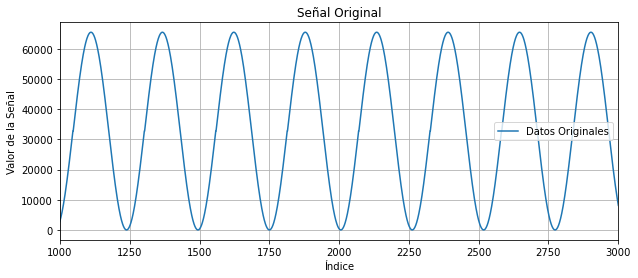

In [23]:
plot_mem_data(data)

In [24]:
def plot_data(data):
    # Graficar los datos y su derivada
    plt.figure(figsize=(10, 4))

    # Graficar los datos originales
    #plt.subplot(2, 1, 1)
    plt.plot(data, label="Datos Originales")
    plt.title("Señal Original")
    plt.xlabel("Índice")
    plt.ylabel("Valor de la Señal")
    plt.grid(True)
    plt.legend()
    plt.xlim([0,8191])
    #plt.ylim([data[1000],data[7000]])
    #plt.show()

In [25]:
my_library.HAL_AFEWriteRegister(hafe0, 2, ctypes.byref((ctypes.c_uint16)(0x00)))
#my_library.HAL_AFE_All0sTest(my_library.hafe0)
#my_library.HAL_AFE_ToggleTest(my_library.hafe0)
#my_library.HAL_AFE_All1sTest(my_library.hafe0)
#my_library.HAL_AFE_CustomTest(my_library.hafe0)
#my_library.HAL_AFE_SkewTest(my_library.hafe0)
#my_library.HAL_AFE_SyncTest(my_library.hafe0)
#my_library.HAL_AFE_RampTest(my_library.hafe0)

writeData = (ctypes.c_uint16)(0x18)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref(writeData))

0

In [26]:
f = open("/dev/mem", "r+b")
    
# Mapear la memoria del DMA
dma_sm = mmap.mmap(f.fileno(), DMA_MAP_SIZE, offset=DMA_DIFF1_ADDR)
dst_sm = mmap.mmap(f.fileno(), DST_MAP_SIZE, offset=DST_DIFF1_ADDR)

['0b1111100010111', '0b1111011010110', '0b1111011010111', '0b1111010010001', '0b1111101000010', '0b1111110000101', '0b1111111000001', '0b1111111010011', '0b1111110100100', '0b1111100110111', '0b1111100001000', '0b1111010100010', '0b1111011011001', '0b1111010111111', '0b1111010010111', '0b1111011010001', '0b1111011101101', '0b1111011111100', '0b1111100001100', '0b1111100100100']


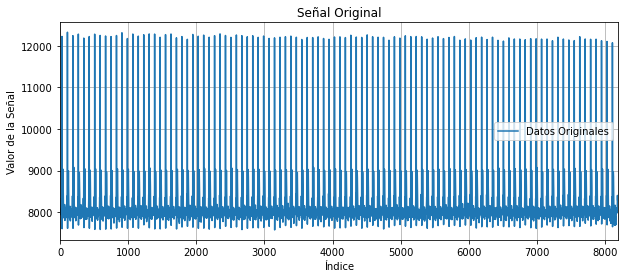

In [31]:
write_dma(dma_sm, S2MM_CONTROL_REGISTER, RESET_DMA)
write_dma(dma_sm, S2MM_CONTROL_REGISTER, HALT_DMA)
write_dma(dma_sm, S2MM_CONTROL_REGISTER, ENABLE_ALL_IRQ)
write_dma(dma_sm, S2MM_DST_ADDRESS_REGISTER, DST_SINE_ADDR)
write_dma(dma_sm, S2MM_CONTROL_REGISTER, RUN_DMA)
write_dma(dma_sm, S2MM_BUFF_LENGTH_REGISTER, DST_MAP_SIZE)

data = get_mem_data(dst_sm, DST_MAP_SIZE)

plot_data(data)

binarios = [bin(num) for num in data[7900:7920]]
print(binarios)

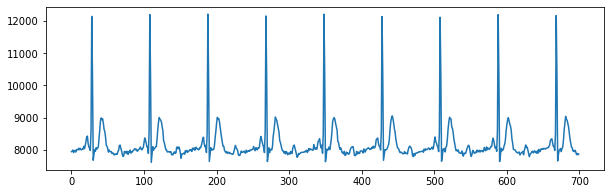

In [32]:
plt.figure(figsize=(10, 3))
plt.plot(data[6000:6700])

---

Funciones para configurar DMA


In [33]:
## funcion de solicitud de datos a DMA
def dma_config(DMA_DIFF_ADDR, DST_DIFF_ADDR):
    f = open("/dev/mem", "r+b")    
    # Mapear la memoria del DMA
    dma_sm = mmap.mmap(f.fileno(), DMA_MAP_SIZE, offset=DMA_DIFF_ADDR)
    dst_sm = mmap.mmap(f.fileno(), DST_MAP_SIZE, offset=DST_DIFF_ADDR)


def dma_data_request():
    '''Function to request data from DMA'''
    write_dma(dma_sm, S2MM_CONTROL_REGISTER, RESET_DMA)
    write_dma(dma_sm, S2MM_CONTROL_REGISTER, HALT_DMA)
    write_dma(dma_sm, S2MM_CONTROL_REGISTER, ENABLE_ALL_IRQ)
    write_dma(dma_sm, S2MM_DST_ADDRESS_REGISTER, DST_SINE_ADDR)
    write_dma(dma_sm, S2MM_CONTROL_REGISTER, RUN_DMA)
    write_dma(dma_sm, S2MM_BUFF_LENGTH_REGISTER, DST_MAP_SIZE)

    data_m = get_mem_data(dst_sm, DST_MAP_SIZE)
    
    return data_m

def print_binary(data_s):
    binarios = [format(num, '014b') for num in data_s[4000:4006]]
    print(binarios)
    
def prueba_data():
    data_r = dma_data_request()
    print_binary(data_r)
    plot_data(data_r)


### Prueba de captura de datos de alineacion

Se hara un protocolo para mirar los datos de alineacion y evaluar el corrimiento de los datos

Alineación de los datos, en delay se pone $1$ y en seleccion se pone $2$

In [28]:
write_devmem(0x80050000, 0x21, bits=32)
write_devmem(0x80050008, 0x21, bits=32)
write_devmem(0x80050010, 0x21, bits=32)
#write_devmem(0x80050004, 2, bits=32)

Valor 0x00000021 escrito en 80050000
Valor 0x00000021 escrito en 80050008
Valor 0x00000021 escrito en 80050010


Prueba de ceros
['00000000000000', '00000000000000', '00000000000000', '00000000000000', '00000000000000', '00000000000000']
---------------------------------------------------


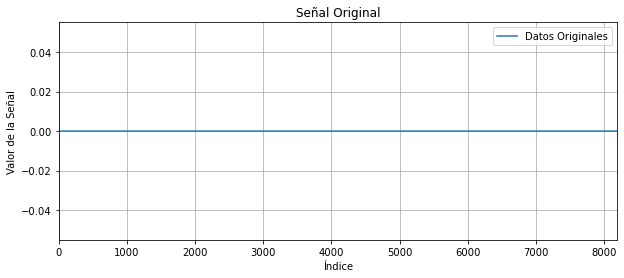

In [35]:
# prueba de todos ceros
my_library.HAL_AFE_All0sTest(my_library.hafe0)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref((ctypes.c_uint16)(0x18)))
print("Prueba de ceros")
prueba_data()
print("---------------------------------------------------")

Prueba de unos
['11111111111111', '11111111111111', '11111111111111', '11111111111111', '11111111111111', '11111111111111']
---------------------------------------------------


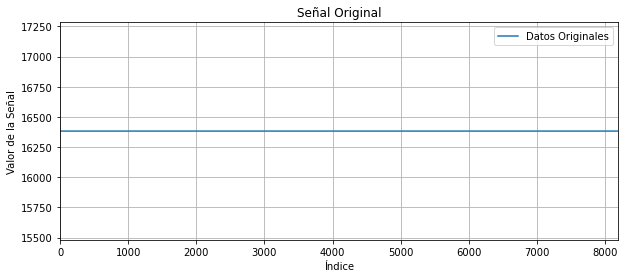

In [37]:
# prueba de todos unos
my_library.HAL_AFE_All1sTest(my_library.hafe0)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref((ctypes.c_uint16)(0x18)))
print("Prueba de unos")
prueba_data()
print("---------------------------------------------------")

Prueba de toggle
['11111111111111', '00000000000000', '11111111111111', '00000000000000', '11111111111111', '00000000000000']
---------------------------------------------------


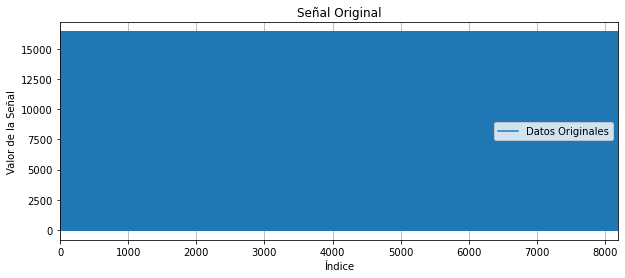

In [40]:
# prueba de toggle
my_library.HAL_AFE_ToggleTest(my_library.hafe0)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref((ctypes.c_uint16)(0x18)))
print("Prueba de toggle")
prueba_data()
print("---------------------------------------------------")

Prueba de deskew
['01010101010101', '01010101010101', '01010101010101', '01010101010101', '01010101010101', '01010101010101']
---------------------------------------------------


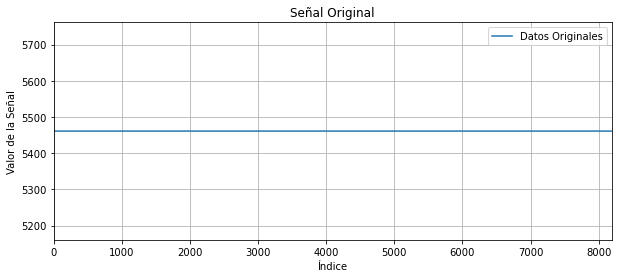

In [42]:
# prueba de deskew
my_library.HAL_AFE_SkewTest(my_library.hafe0)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref((ctypes.c_uint16)(0x18)))
print("Prueba de deskew")
prueba_data()
print("---------------------------------------------------")

Prueba de sync
['11111110000000', '11111110000000', '11111110000000', '11111110000000', '11111110000000', '11111110000000']
---------------------------------------------------


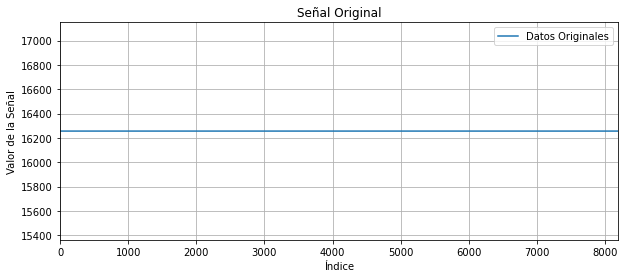

In [45]:
# prueba de Sync
my_library.HAL_AFE_SyncTest(my_library.hafe0)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref((ctypes.c_uint16)(0x18)))
print("Prueba de sync")
prueba_data()
print("---------------------------------------------------")

Prueba de ramp
['01100000101101', '01100000101110', '01100000101111', '01100000110000', '01100000110001', '01100000110010']
---------------------------------------------------


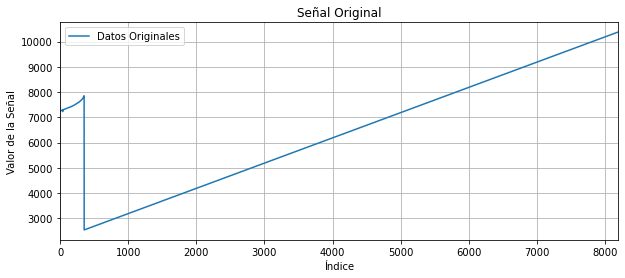

In [49]:
# prueba de ramp
my_library.HAL_AFE_RampTest(my_library.hafe0)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref((ctypes.c_uint16)(0x18)))
print("Prueba de ramp")
prueba_data()
print("---------------------------------------------------")

In [60]:
bin_value = read_devmem_binary("0x80050004")
print("Valor binario:", bin_value)
bin_value = read_devmem_binary("0x8005000C")
print("Valor binario:", bin_value)
bin_value = read_devmem_binary("0x80050014")
print("Valor binario:", bin_value)

Valor binario: 11001011000101110110110001011110
Valor binario: 11100010010010111000101000101110
Valor binario: 10110110011011111101100111000011


### Prueba channel 2

Prueba channel 2

In [61]:
my_library.HAL_AFEWriteRegister(hafe0, 2, ctypes.byref((ctypes.c_uint16)(0x00)))

writeData = (ctypes.c_uint16)(0x18)
my_library.HAL_AFEWriteRegister(hafe0, 4, ctypes.byref(writeData))

0

In [62]:
f = open("/dev/mem", "r+b")

DST_ADDR_TMP = 0x00100000

# Mapear la memoria del DMA
dma_sm = mmap.mmap(f.fileno(), DMA_MAP_SIZE, offset=DMA_DIFF3_ADDR)
dst_sm = mmap.mmap(f.fileno(), DST_MAP_SIZE, offset=DST_ADDR_TMP)

['0b1111010001110', '0b1111010001100', '0b1111010101111', '0b1111010000001', '0b1111010000101', '0b1111010010011', '0b1111001110110', '0b1111001010000', '0b1111011000001', '0b1111010001110', '0b1111010111010', '0b1111010111111', '0b1111010101101', '0b1111010010110', '0b1111011101110', '0b1111010101010', '0b1111010110001', '0b1111011101100', '0b1111011100010', '0b1111011110100']


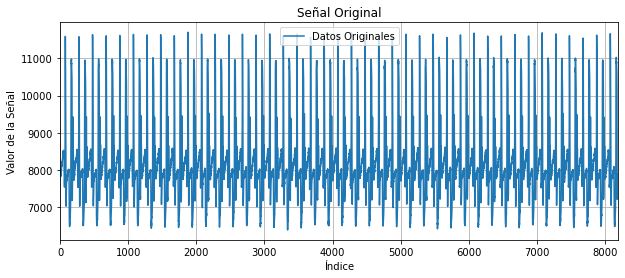

In [64]:
write_dma(dma_sm, S2MM_CONTROL_REGISTER, RESET_DMA)
write_dma(dma_sm, S2MM_CONTROL_REGISTER, HALT_DMA)
write_dma(dma_sm, S2MM_CONTROL_REGISTER, ENABLE_ALL_IRQ)
write_dma(dma_sm, S2MM_DST_ADDRESS_REGISTER, DST_ADDR_TMP)
write_dma(dma_sm, S2MM_CONTROL_REGISTER, RUN_DMA)
write_dma(dma_sm, S2MM_BUFF_LENGTH_REGISTER, DST_MAP_SIZE)

data = get_mem_data(dst_sm, DST_MAP_SIZE)

plot_data(data)

binarios = [bin(num) for num in data[7900:7920]]
print(binarios)

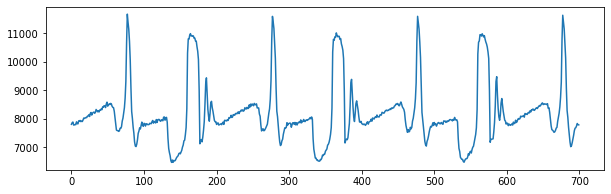

In [65]:
plt.figure(figsize=(10, 3))
plt.plot(data[6000:6700])